In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("/content/placement (3).csv")

In [4]:
df.sample(5)

,cgpa,placement_exam_marks,placed
274,7.13,4.0,1
557,6.47,25.0,0
725,6.34,10.0,0
751,6.69,20.0,1
390,6.63,16.0,1


/tmp/ipython-input-2811730937.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
/tmp/ipython-input-2811730937.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


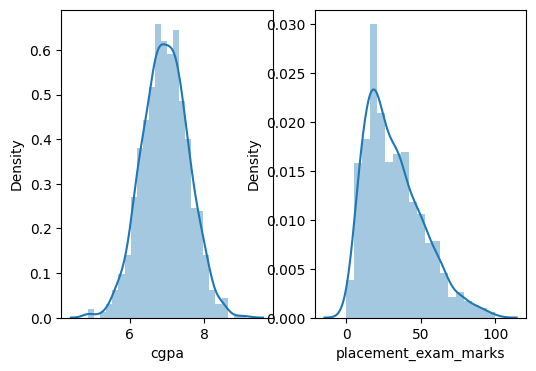

In [18]:
plt.figure(figsize=(6,4))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

In [19]:
print("mean of the cgpa" , df['cgpa'].mean())
print("std of the cgpa" , df['cgpa'].std())
print("min of the cgpa" , df['cgpa'].min())
print("max of the cgpa" , df['cgpa'].max())

mean of the cgpa 6.96124
std of the cgpa 0.6158978751323894
min of the cgpa 4.89
max of the cgpa 9.12


In [20]:
#calculating the boundery values
print('Heighest value allowed ' , df['cgpa'].mean() + 3*df['cgpa'].std())
print("lowest value allowed ", df['cgpa'].mean() - 3*df['cgpa'].std())

Heighest value allowed  8.808933625397168
lowest value allowed  5.113546374602832


In [21]:
#find the outliers
df[(df['cgpa']<5.11) | (df['cgpa']>8.80)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [22]:
#REMOVING THE OUTLIERS
#1. TRIMMIN G- REMOVING THE VALUES FROM THE TABLE
new_df = df[(df['cgpa']>5.11)&(df['cgpa']<8.80 )]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [23]:
#approch 2
#calculating thez score for all the values
#FORMULA - xi_new = (xi-mean)/standard deviation
df['cgpa_zscore'] = (df['cgpa']-df['cgpa'].mean()) / df['cgpa'].std()

In [24]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [26]:
df[(df['cgpa_zscore']>3) | (df['cgpa_zscore']<-3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [28]:
new_df = df[(df['cgpa_zscore']<3) | (df['cgpa_zscore']>-3)]

In [29]:
#2 . CAPPING
#REPLACING THE VALUES OF THE OUTLIERS WITH HEIGHEST AND LOWEST LIMIT
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [30]:
df['cgpa'] = np.where(df['cgpa']>upper_limit,upper_limit, np.where(df['cgpa']<lower_limit , lower_limit , df['cgpa']))

In [ ]:
#np.where(condition , if condition is tru , if condition is false )
#np.where(df['cgpa]).upper_limit , upper_limit , np.where(df['cgpa]>lower_limit , lower_limit , df['cgpa]))

In [32]:
df.shape

(1000, 4)

In [33]:
df['cgpa'].describe()

,cgpa
count,1000.000000
mean,6.961499
std,0.612688
min,5.113546
25%,6.550000
50%,6.960000
75%,7.370000
max,8.808934


In [31]:
upper_limit

np.float64(8.808933625397168)